In [ ]:
import os
import cv2
import numpy as np
import joblib
import json
import csv
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Directories for caching and outputs
dirs = {
    'cache': './cache',
    'models': './models',
    'results': './results'
}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)

# Parameter grids
descriptor_types = ['ORB', 'SIFT']
k_clusters_list = [50, 100, 200]
svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}

# Utility functions for caching
def cache_path(name, ext, directory):
    return os.path.join(dirs[directory], f"{name}.{ext}")

# 1. Load images and labels (recursive) 
def load_images_and_labels(base_path):
    image_paths, labels = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    for idx, cls in enumerate(class_names):
        cls_dir = os.path.join(base_path, cls)
        # walk all nested folders
        for root, _, files in os.walk(cls_dir):
            for fname in files:
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.ppm')):
                    image_paths.append(os.path.join(root, fname))
                    labels.append(idx)
    return image_paths, labels, class_names

# 2. Extract descriptors (with caching)
def extract_descriptors(image_paths, descriptor_type):
    cache_file = cache_path(f"descriptors_{descriptor_type}", 'pkl', 'cache')
    if os.path.exists(cache_file):
        print(f"Loading cached descriptors for {descriptor_type}...")
        all_desc, desc_per_image = joblib.load(cache_file)
        return all_desc, desc_per_image

    print(f"Extracting {descriptor_type} descriptors...")
    if descriptor_type == 'SIFT':
        descriptor = cv2.SIFT_create()
    else:
        descriptor = cv2.ORB_create(nfeatures=500)

    all_desc = []
    desc_per_image = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            desc_per_image.append(None)
            continue
        _, desc = descriptor.detectAndCompute(img, None)
        desc_per_image.append(desc)
        if desc is not None:
            all_desc.extend(desc)
    all_desc = np.array(all_desc)
    joblib.dump((all_desc, desc_per_image), cache_file)
    return all_desc, desc_per_image

# 3. Build or load KMeans vocabulary
def get_kmeans(descriptors, descriptor_type, k):
    name = f"kmeans_{descriptor_type}_{k}"
    cache_file = cache_path(name, 'joblib', 'models')
    if os.path.exists(cache_file):
        print(f"Loading cached KMeans for {descriptor_type}, k={k}...")
        return joblib.load(cache_file)

    print(f"Fitting KMeans for {descriptor_type}, k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, verbose=0)
    kmeans.fit(descriptors)
    joblib.dump(kmeans, cache_file)
    return kmeans

# 4. Compute histograms of visual words
def compute_histograms(kmeans, desc_per_image, k):
    histograms = []
    for desc in desc_per_image:
        if desc is None:
            hist = np.zeros(k)
        else:
            words = kmeans.predict(desc)
            hist, _ = np.histogram(words, bins=np.arange(k+1))
            hist = hist.astype(float) / (hist.sum() + 1e-7)
        histograms.append(hist)
    return np.array(histograms)

# 5. Train and evaluate, saving results
def train_and_evaluate(X, y, descriptor_type, k):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    svc = SVC()
    grid = GridSearchCV(svc, svm_param_grid, cv=5, n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    params = grid.best_params_
    y_pred = best.predict(X_test)

    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Save model and metrics
    model_path = cache_path(f"svm_{descriptor_type}_{k}", 'joblib', 'models')
    joblib.dump(best, model_path)
    with open(cache_path(f"report_{descriptor_type}_{k}", 'json', 'results'), 'w') as f:
        json.dump(report, f, indent=2)
    np.save(cache_path(f"cm_{descriptor_type}_{k}", 'npy', 'results'), cm)

    # Append summary to CSV
    csv_file = cache_path('results_summary', 'csv', 'results')
    header = ['descriptor', 'k', 'C', 'kernel', 'accuracy']
    row = [descriptor_type, k, params['C'], params['kernel'], report['accuracy']]
    write_header = not os.path.exists(csv_file)
    with open(csv_file, 'a', newline='') as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(header)
        writer.writerow(row)

# Main routine
def main():
    base_path = '/home/mscrobotics2425laptop24/Documents/SEM_2/comp_vision_2/CV_3/dataset/iCubWorld/train'
    image_paths, labels, class_names = load_images_and_labels(base_path)
    print(f"Loaded {len(image_paths)} images across {len(class_names)} classes.")

    # Loop over descriptor types
    for descriptor in descriptor_types:
        all_desc, desc_per_image = extract_descriptors(image_paths, descriptor)
        print(f"Total descriptors for {descriptor}: {all_desc.shape[0]}")

        # Loop over cluster sizes
        for k in k_clusters_list:
            try:
                kmeans = get_kmeans(all_desc, descriptor, k)
                hists = compute_histograms(kmeans, desc_per_image, k)
                train_and_evaluate(hists, labels, descriptor, k)
                print(f"Completed run: {descriptor}, k={k}")
            except Exception as e:
                # Log errors
                err_file = cache_path('error_log', 'txt', 'results')
                with open(err_file, 'a') as ef:
                    ef.write(f"Error with {descriptor}, k={k}: {e}\n")
                print(f"Error on {descriptor}, k={k}. Check {err_file}.")

if __name__ == '__main__':
    main()


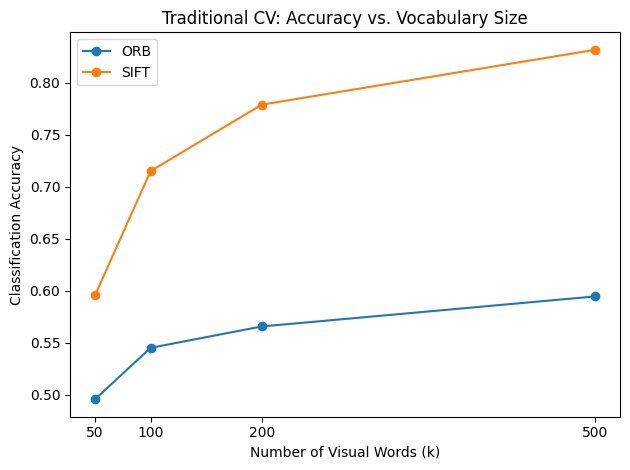

In [6]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Your local results folder:
results_dir = '/home/mscrobotics2425laptop24/Documents/SEM_2/comp_vision_2/CV_3/results'

# 2. Locate the summary CSV
summary_files = glob.glob(os.path.join(results_dir, '*summary*.csv'))
if not summary_files:
    raise FileNotFoundError(f"No '*summary*.csv' found under {results_dir}")
csv_path = summary_files[0]

# 3. Load & pivot
df = pd.read_csv(csv_path)
pivot_df = df.pivot(index='k', columns='descriptor', values='accuracy')

# 4. Convert to NumPy for plotting
ks = pivot_df.index.to_numpy()
orb_acc = pivot_df['ORB'].to_numpy()
sift_acc = pivot_df['SIFT'].to_numpy()

# 5. Plot
plt.figure()
plt.plot(ks, orb_acc, marker='o', label='ORB')
plt.plot(ks, sift_acc, marker='o', label='SIFT')
plt.xlabel('Number of Visual Words (k)')
plt.ylabel('Classification Accuracy')
plt.title('Traditional CV: Accuracy vs. Vocabulary Size')
plt.xticks(ks)           # ensure the k values show on the x-axis
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
import os
import cv2
import numpy as np
import joblib
import json
import csv
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Directories for caching and outputs
dirs = {'cache': './cache', 'models': './models', 'results': './results'}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)

# Parameter grids
descriptor_types = ['ORB', 'SIFT']
k_clusters_list = [50, 100, 200, 500]
svm_param_grid = {'C': [0.01, 0.1, 1, 10], 'kernel': ['linear', 'rbf']}

# Caching helper
def cache_path(name, ext, directory):
    return os.path.join(dirs[directory], f"{name}.{ext}")

# 1. Load images and labels (recursive)
def load_images_and_labels(base_path):
    image_paths, labels = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    for idx, cls in enumerate(class_names):
        cls_dir = os.path.join(base_path, cls)
        for root, _, files in os.walk(cls_dir):
            for fname in files:
                if fname.lower().endswith(('.png','.jpg','.jpeg','.ppm')):
                    image_paths.append(os.path.join(root, fname))
                    labels.append(idx)
    return image_paths, labels, class_names

# 2. Extract descriptors (with RootSIFT for SIFT, caching)
def extract_descriptors(image_paths, descriptor_type):
    cache_file = cache_path(f"desc_{descriptor_type}", 'pkl', 'cache')
    if os.path.exists(cache_file):
        return joblib.load(cache_file)

    if descriptor_type == 'SIFT':
        extractor = cv2.SIFT_create()
    else:
        extractor = cv2.ORB_create(nfeatures=800)

    all_desc = []
    desc_per_image = []
    for p in image_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            desc_per_image.append(None)
            continue
        _, desc = extractor.detectAndCompute(img, None)
        if desc is not None and descriptor_type == 'SIFT':
            # RootSIFT normalization
            desc = desc.astype(np.float32)
            desc /= (np.linalg.norm(desc, ord=1, axis=1, keepdims=True) + 1e-7)
            desc = np.sqrt(desc)
        desc_per_image.append(desc)
        if desc is not None:
            all_desc.extend(desc)
    all_desc = np.array(all_desc)
    joblib.dump((all_desc, desc_per_image), cache_file)
    return all_desc, desc_per_image

# 3. Build or load KMeans vocabulary
def get_kmeans(descriptors, descriptor_type, k):
    name = f"kmeans_{descriptor_type}_{k}"
    cache_file = cache_path(name, 'joblib', 'models')
    if os.path.exists(cache_file):
        return joblib.load(cache_file)

    kmeans = KMeans(n_clusters=k, random_state=42, verbose=0)
    kmeans.fit(descriptors)
    joblib.dump(kmeans, cache_file)
    return kmeans

# 4. Compute histograms + TF-IDF weighting
def compute_histograms(kmeans, desc_per_image, k):
    hists = []
    for desc in desc_per_image:
        if desc is None:
            hists.append(np.zeros(k))
        else:
            words = kmeans.predict(desc)
            hist, _ = np.histogram(words, bins=np.arange(k+1))
            hist = hist.astype(float)
            hist /= (hist.sum() + 1e-7)
            hists.append(hist)
    H = np.vstack(hists)
    # compute IDF vector
    N = H.shape[0]
    df = np.sum(H > 0, axis=0)
    idf = np.log((N + 1) / (df + 1))
    # apply TF-IDF
    H = H * idf
    # L2 normalize
    norms = np.linalg.norm(H, axis=1, keepdims=True) + 1e-7
    H = H / norms
    return H

# 5. Train & evaluate SVM, saving results
def train_and_evaluate(X, y, descriptor_type, k):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                        random_state=42, stratify=y)
    svc = SVC()
    grid = GridSearchCV(svc, svm_param_grid, cv=5, n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    params = grid.best_params_
    y_pred = best.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Save
    joblib.dump(best, cache_path(f"svm_{descriptor_type}_{k}", 'joblib', 'models'))
    with open(cache_path(f"report_{descriptor_type}_{k}", 'json', 'results'), 'w') as f:
        json.dump(report, f, indent=2)
    np.save(cache_path(f"cm_{descriptor_type}_{k}", 'npy', 'results'), cm)
    # summary CSV
    csv_file = cache_path('results_summary', 'csv', 'results')
    write_header = not os.path.exists(csv_file)
    row = [descriptor_type, k, params['C'], params['kernel'], report['accuracy']]
    with open(csv_file, 'a', newline='') as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(['descriptor','k','C','kernel','accuracy'])
        writer.writerow(row)

# Main pipeline
def main():
    base_path = '/home/mscrobotics2425laptop24/Documents/SEM_2/comp_vision_2/CV_3/dataset/iCubWorld/train'  # update path
    image_paths, labels, class_names = load_images_and_labels(base_path)
    for descriptor in descriptor_types:
        all_desc, desc_per_image = extract_descriptors(image_paths, descriptor)
        for k in k_clusters_list:
            kmeans = get_kmeans(all_desc, descriptor, k)
            H = compute_histograms(kmeans, desc_per_image, k)
            train_and_evaluate(H, labels, descriptor, k)
            print(f"Completed {descriptor}, k={k}")

if __name__ == '__main__':
    main()


Completed ORB, k=50
Completed ORB, k=100
Completed ORB, k=200
Completed ORB, k=500
Completed SIFT, k=50
Completed SIFT, k=100
Completed SIFT, k=200
Completed SIFT, k=500


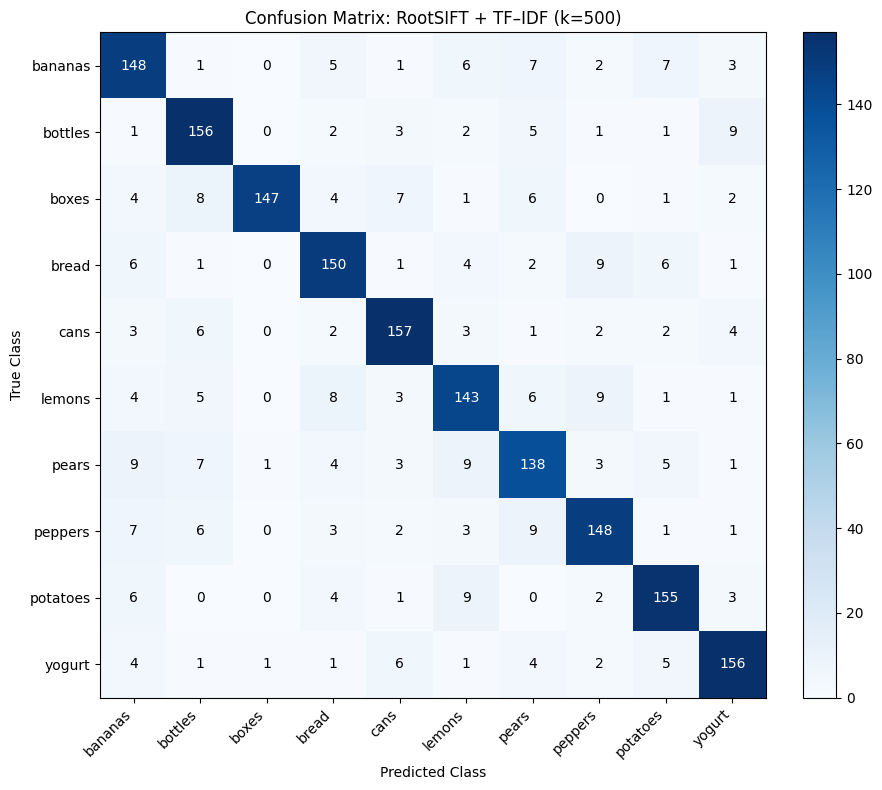

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

# 1. Paths  
data_dir = r'/home/mscrobotics2425laptop24/Documents/SEM_2/comp_vision_2/CV_3/dataset/iCubWorld/train'  # <-- update this
cm_path  = os.path.join('results', 'cm_SIFT_500.npy')

# 2. Load confusion matrix
cm = np.load(cm_path)

# 3. Load class names (must match the order used in your training script)
dataset = ImageFolder(data_dir)
class_names = dataset.classes  # e.g. ['bananas','bottles','boxes',...]

# 4. Plot
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix: RootSIFT + TF–IDF (k=500)')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')

# Tick labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

# Annotate counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('confusion_matrix_sift_k500_labeled.png')
plt.show()


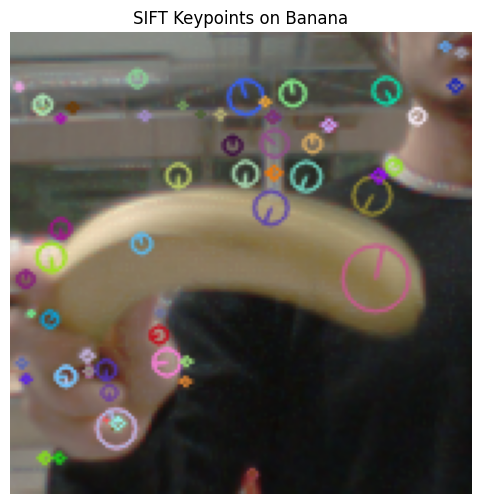

In [11]:
import cv2
import os
import matplotlib.pyplot as plt

# ==== UPDATE THESE PATHS ====
sample_img = r'/home/mscrobotics2425laptop24/Documents/SEM_2/comp_vision_2/CV_3/dataset/iCubWorld/train/bananas/banana_1/00000000.ppm'
output_path = 'sift_keypoints.png'

# Load
img = cv2.imread(sample_img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()
kps, _ = sift.detectAndCompute(gray, None)
kps = kps[:200]  # top 200

# Draw
img_kp = cv2.drawKeypoints(img, kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Save & show
cv2.imwrite(output_path, img_kp)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('SIFT Keypoints on Banana')
plt.show()


In [17]:
import os, pickle, joblib, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import cv2

# ==== USER CONFIGURATION ====
# Path to your iCubWorld train folder (containing class subdirs)
base_path = r'/home/mscrobotics2425laptop24/Documents/SEM_2/comp_vision_2/CV_3/dataset/iCubWorld/train'

# k for SIFT vocabulary
k = 500

# Cache/model paths
desc_cache   = 'cache/desc_SIFT.pkl'
kmeans_model = f'models/kmeans_SIFT_{k}.joblib'
svm_model    = f'models/svm_SIFT_{k}.joblib'

# Output directory
out_dir = 'results'
os.makedirs(out_dir, exist_ok=True)

# --- Helper: recursively load image paths and labels ---
def load_images_and_labels(root):
    paths, labels = [], []
    classes = sorted(d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)))
    for idx, cls in enumerate(classes):
        for r, _, fnames in os.walk(os.path.join(root, cls)):
            for f in fnames:
                if f.lower().endswith(('.png','.jpg','.jpeg','.ppm')):
                    paths.append(os.path.join(r, f))
                    labels.append(idx)
    return paths, labels, classes

# --- Helper: compute TF–IDF histograms ---
def compute_histograms(kmeans, desc_list, k):
    # build raw histograms
    H = []
    for desc in desc_list:
        if desc is None:
            hist = np.zeros(k, dtype=float)
        else:
            words = kmeans.predict(desc)
            hist, _ = np.histogram(words, bins=np.arange(k+1))
            hist = hist.astype(float) / (hist.sum() + 1e-7)
        H.append(hist)
    H = np.vstack(H)
    # TF–IDF weighting
    N = H.shape[0]
    df = np.count_nonzero(H > 0, axis=0)
    idf = np.log((N + 1) / (df + 1))
    H = H * idf
    # L2 normalize
    norms = np.linalg.norm(H, axis=1, keepdims=True) + 1e-7
    return H / norms

# 1. Load image paths & labels
image_paths, labels, class_names = load_images_and_labels(base_path)
labels = np.array(labels)

# 2. Load cached descriptors and per-image lists
all_desc, descs_per_image = joblib.load(desc_cache)

# 3. Load KMeans and build H
kmeans = joblib.load(kmeans_model)
H = compute_histograms(kmeans, descs_per_image, k)

# 4. Split into train/test exactly as earlier
idx = np.arange(len(labels))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, labels, test_size=0.3, stratify=labels, random_state=42)

# 5. Load SVM and predict on test set
svm = joblib.load(svm_model)
y_pred = svm.predict(H[idx_test])

# 6. (Optional) recompute & save confusion matrix to verify
cm = confusion_matrix(y_test, y_pred)
np.save(os.path.join(out_dir, f'cm_recomputed_SIFT_{k}.npy'), cm)

# 7. Save everything needed for histogram plotting
np.save(os.path.join(out_dir, f'H_SIFT_{k}.npy'), H)
np.save(os.path.join(out_dir, 'test_idx.npy'),   idx_test)
np.save(os.path.join(out_dir, 'y_test.npy'),     y_test)
np.save(os.path.join(out_dir, 'y_pred.npy'),     y_pred)
with open(os.path.join(out_dir, 'classes.pkl'), 'wb') as f:
    pickle.dump(class_names, f)

print("✅ Post-processing complete. Files saved in 'results/':")
print("   H_SIFT_500.npy, test_idx.npy, y_test.npy, y_pred.npy, classes.pkl")
print("   cm_recomputed_SIFT_500.npy") 


✅ Post-processing complete. Files saved in 'results/':
   H_SIFT_500.npy, test_idx.npy, y_test.npy, y_pred.npy, classes.pkl
   cm_recomputed_SIFT_500.npy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# === Paths (adjust if needed) ===
H_path        = 'results/H_SIFT_500.npy'
test_idx_path = 'results/test_idx.npy'
y_true_path   = 'results/y_test.npy'
y_pred_path   = 'results/y_pred.npy'
classes_path  = 'results/classes.pkl'

# 1. Load data
H        = np.load(H_path)
test_idx = np.load(test_idx_path)
y_true   = np.load(y_true_path)
y_pred   = np.load(y_pred_path)
with open(classes_path, 'rb') as f:
    class_names = pickle.load(f)

# 2. Find one correct and one wrong example
correct_local, wrong_local = None, None
for local_i, (t, p) in enumerate(zip(y_true, y_pred)):
    if t == p and correct_local is None:
        correct_local = local_i
    if t != p and wrong_local is None:
        wrong_local = local_i
    if correct_local is not None and wrong_local is not None:
        break

# Map back to rows of H
H_corr  = H[test_idx[correct_local], :]
H_wrong = H[test_idx[wrong_local], :]

# 3. Plot
plt.figure(figsize=(10,4))
plt.plot(H_corr,  label=f'Correct: {class_names[y_true[correct_local]]}')
plt.plot(H_wrong, label=f'Misclassified: {class_names[y_pred[wrong_local]]}')
plt.title('TF–IDF Histogram Comparison')
plt.xlabel('Visual Word Index')
plt.ylabel('TF–IDF Weight')
plt.legend(loc='upper right')
plt.tight_layout()

# Save & show
out_path = 'bovw_histogram_example.png'
plt.savefig(out_path, dpi=150)
print(f"Saved histogram comparison to {out_path}")
plt.show()


In [8]:
# %%capture
# Install any missing dependencies if needed
# !pip install torchvision scikit-learn pandas

# -------------------------------------------------------------------
# Imports
# -------------------------------------------------------------------
import os
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Import your BoVW inference function
# Adjust the import path to where you've defined bovw_infer(...)
from measure_power import bovw_infer  

# -------------------------------------------------------------------
# 1. Load dataset and reproduce splits
# -------------------------------------------------------------------
data_dir = r"C:\Users\Mahir\Documents\COMPVISION\datatset\iCubWorld\train"  # update as needed

# Use the same split logic as your training script
full_dataset = ImageFolder(data_dir, transform=None)
labels = [label for _, label in full_dataset.samples]
indices = list(range(len(full_dataset)))

# First split: train vs temp
train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, labels, test_size=0.3, stratify=labels, random_state=42
)

# Second split: val vs test (50/50 of temp)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

# Map class indices to names
class_names = full_dataset.classes

# -------------------------------------------------------------------
# 2. Build ground-truth labels (y_true)
# -------------------------------------------------------------------
y_true = [ full_dataset.samples[i][1] for i in test_idx ]

# -------------------------------------------------------------------
# 3. Run BoVW inference to get predictions (y_pred)
# -------------------------------------------------------------------
y_pred = []
for idx in test_idx:
    img_path, _ = full_dataset.samples[idx]
    pred_label = bovw_infer(img_path)  # must return integer class index
    y_pred.append(pred_label)

print("y_true types:", set(type(v) for v in y_true))
print("y_pred types:", set(type(v) for v in y_pred))
print("Unique true labels:", sorted(set(y_true)))
print("Unique pred labels:", sorted(set(y_pred)))

# -------------------------------------------------------------------
# 4. Compute per-class precision, recall, F1
# -------------------------------------------------------------------
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
)

# -------------------------------------------------------------------
# 5. Tabulate and display
# -------------------------------------------------------------------
df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

# Round for readability
df_metrics[["Precision","Recall","F1-score"]] = df_metrics[["Precision","Recall","F1-score"]].round(3)

display(df_metrics)


y_true types: {<class 'int'>}
y_pred types: {<class 'NoneType'>}
Unique true labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unique pred labels: [None]


ValueError: Classification metrics can't handle a mix of multiclass and unknown targets